--- First 5 Rows of Marketing_Sales (Analyst: SF) ---
  Campaign_ID   TV_Budget  Social_Media_Budget  Newspaper_Budget      Sales
0      SF_001  218.543053           142.650726         22.587628  46.831348
1      SF_002  477.821438           111.858310         56.480590  64.172259
2      SF_003  379.397274            68.810247         87.929854  44.455862
3      SF_004  319.396318           164.621054         74.561364  58.056422
4      SF_005  120.208388           140.098923         81.623309  49.089599

X_train shape: (350, 3)
X_test shape: (150, 3)

--- Model Results for Roll No: 42 ---
Intercept: 14.2744
Coefficients (TV, Social, News): [0.051223   0.18190599 0.01332557]
R2 Score: 0.9668
MAE: 1.7269
MSE: 4.8812

--- Actual vs Predicted Sales (First 10 for SF) ---
        Actual  Predicted
361  50.690788  49.482593
73   64.149646  59.041205
374  21.122754  21.552568
155  27.250898  29.663053
104  45.179877  45.069901
394  49.733787  50.093974
377  41.832492  42.683229
124  44.673355

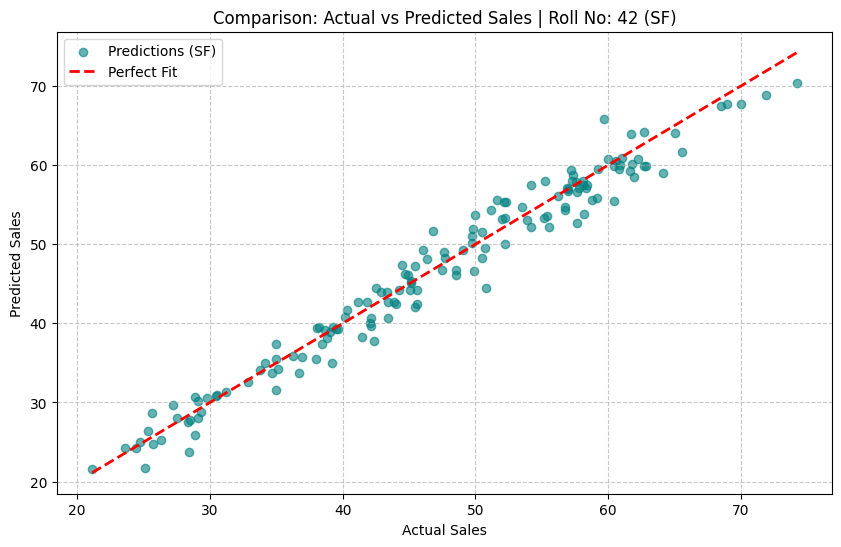

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


ROLL_NO = 42
INITIALS = "SF"
np.random.seed(ROLL_NO)
n = 500

# 1. Data Generation & Preparation
tv = np.random.uniform(50, 500, n)
social = np.random.uniform(10, 200, n)
news = np.random.uniform(5, 100, n)
noise = np.random.normal(0, 2, n)

# Computing Sales using a custom formula for SF
sales = 15 + (0.05 * tv) + (0.18 * social) + (0.01 * news) + noise

# Creating DataFrame with unique Campaign IDs for SF
Marketing_Sales = pd.DataFrame({
    'Campaign_ID': [f"{INITIALS}_{i:03d}" for i in range(1, n + 1)],
    'TV_Budget': tv,
    'Social_Media_Budget': social,
    'Newspaper_Budget': news,
    'Sales': sales
})

print(f"--- First 5 Rows of Marketing_Sales (Analyst: {INITIALS}) ---")
print(Marketing_Sales.head())

# Identifying Variables
X = Marketing_Sales[['TV_Budget', 'Social_Media_Budget', 'Newspaper_Budget']]
y = Marketing_Sales['Sales']

# 2. Train-Test Split (70:30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=ROLL_NO)

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# 3. Model Implementation (Manual Normal Equation)
X_b = np.c_[np.ones((X_train.shape[0], 1)), X_train.values]
y_b = y_train.values.reshape(-1, 1)

# Normal Equation: theta = (X^T * X)^-1 * X^T * y
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y_b)

intercept = theta_best[0][0]
coefficients = theta_best[1:].flatten()

# 4. Model Evaluation
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test.values]
y_pred = X_test_b.dot(theta_best).flatten()

# Metrics Calculation
mae = np.mean(np.abs(y_test - y_pred))
mse = np.mean((y_test - y_pred)**2)
ss_res = np.sum((y_test - y_pred)**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)
r2 = 1 - (ss_res / ss_tot)

print(f"\n--- Model Results for Roll No: {ROLL_NO} ---")
print(f"Intercept: {intercept:.4f}")
print(f"Coefficients (TV, Social, News): {coefficients}")
print(f"R2 Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")

# 5. Prediction & Analysis
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(f"\n--- Actual vs Predicted Sales (First 10 for {INITIALS}) ---")
print(comparison_df.head(10))

# Plotting with personalized labels
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='teal', alpha=0.6, label=f'Predictions ({INITIALS})')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.title(f'Comparison: Actual vs Predicted Sales | Roll No: {ROLL_NO} ({INITIALS})')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()